# Shovel MCTS vanilla Scratchpad
Full pipeline of MCTS vanille planning integrated with pybullet simulation and control of a single shovel link as a 2D Cartesian robot with two prismatic joints (X, Y) and one revolute joint (orientation)

## Section 1: Import Required Libraries

In [1]:
import os
import sys

import numpy as np
import cv2
from numpy.random import seed
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time as t

from push_environment_gym_wrapper import PushEnvironmentGym
from preprocess_environment_v1 import PreprocessEnvironment


project_root = os.path.dirname(os.path.dirname(os.getcwd()))
env_path = os.path.join(project_root, "clutter", "shovel")
sys.path.append(env_path)

# Import the shovel controller
from shovel_controller import ShovelController, initialize_simulation, load_shovel, scatter_pebbles
from shovel_env import ShovelEnvironment

# seed random number generator
seed(42)

pybullet build time: Jan 29 2025 23:16:28


## Section 2: Initialize Simulation and Load Models


In [2]:
# physics_env = ShovelEnvironment(working_area_bounds={'x_min': 0.1, 'x_max': 0.6, 'y_min': -0.25, 'y_max': 0.25}, gui=True)
physics_env = ShovelEnvironment(working_area_bounds={'x_min': 0.1, 'x_max': 0.6, 'y_min': -0.25, 'y_max': 0.25}, gui=False)

shovel_urdf_path = os.path.join(env_path, "urdf/shovel/shovelFlat.urdf")
pebble_urdf_path = os.path.join(env_path, "urdf/pebbles/pebbles.urdf")

physics_client = physics_env.initialize_environment(shovel_urdf_path)

# Load the shovel robot
robot_id = physics_env.robot_id
print(f"✓ Shovel loaded: robotId = {robot_id}")

# Optionally scatter pebbles in the workspace
# pebble_ids = scatter_pebbles(num_pebbles=500, min_pos=[0.1, -0.5, 0], max_pos=[1.5, 0.5, 0])
pebble_ids = physics_env.load_pebbles(num_pebbles=100, pebble_urdf=pebble_urdf_path, min_pos=[0.1, -0.25, 0], max_pos=[0.6, 0.25, 0])
print(f"✓ Scattered {len(pebble_ids)} pebbles in workspace area")

# Create the controller
controller = physics_env.controller
print(f"✓ ShovelController initialized")


# Optionally scatter pebbles in the workspace
# pebble_ids = scatter_pebbles(num_pebbles=500, min_pos=[0.1, -0.5, 0], max_pos=[1.5, 0.5, 0])
# pebble_ids = scatter_pebbles(num_pebbles=100, pebble_urdf=pebble_urdf_path, min_pos=[0.1, -0.25, 0], max_pos=[0.6, 0.25, 0])
# pebble_ids = scatter_pebbles(num_pebbles=100, pebble_urdf=pebble_urdf_path, min_pos=[0.2, -0.15, 0], max_pos=[0.5, 0.15, 0])



✓ Shovel loaded: robotId = 1
✓ Scattered 97 pebbles in workspace area
✓ ShovelController initialized


[ 22  24  25  26  27  28  29  30  31  46  47  49  50 152 197]


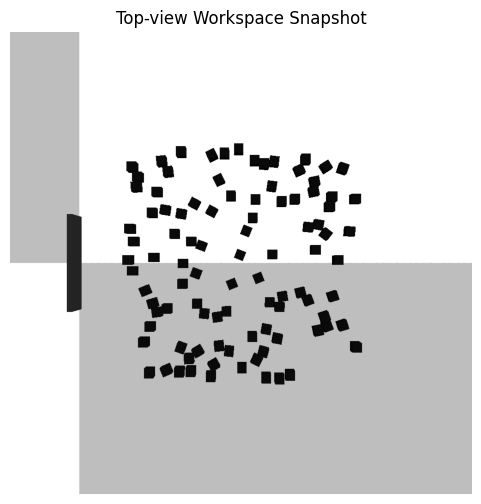

In [3]:
# Capture and display workspace top-view
top_view_gray = controller.get_top_view(pixel_width=1000, pixel_height=1000, camera_target_pos=[0.35, 0, 0], camera_distance=0.866)

# Save to output directory
# snapshot_path = controller.save_top_view()

print(np.unique(top_view_gray[:, :, 0]))

# Display in notebook
plt.figure(figsize=(6, 6))
plt.imshow(top_view_gray[:, :, 0], cmap='gray')
plt.title('Top-view Workspace Snapshot')
plt.axis('off')
plt.show()

# print(f"✓ Snapshot saved to: {snapshot_path.resolve()}")

[ 22  24  25  26  27  28  29  30  31 152 197]


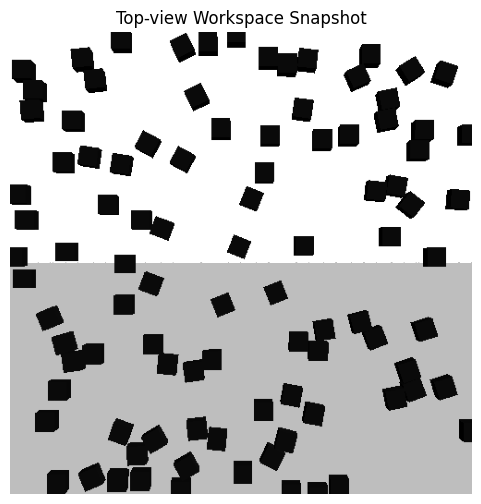

In [4]:
img_cropped = top_view_gray[250:750, 250:750, :]
print(np.unique(img_cropped[:, :, 0]))

plt.figure(figsize=(6, 6))
plt.imshow(img_cropped[:, :, 0], cmap='gray')
plt.title('Top-view Workspace Snapshot')
plt.axis('off')
plt.show()

## Define Algortihm Environment parameters

In [5]:
# Define environment and agent parameters
SQUARE_SIZE = 500  # size of the square area in the top-down view (in pixels)
# grid_size = 25 # number of cells in the grid (e.g., 25x25)
# grid_size = 24 # number of cells in the grid
grid_size = 16 # number of cells in the grid
shovel_width = 0.25 # width of the shovel in the same units as the grid (e.g., 0.25 for 25% of the full grid size)
# shovel_width = 0.26 # width of the shovel in the same units as the grid (e.g., 0.25 for 25% of the full grid size)
s0 = 0  # Start at the first boundary oint
max_pushes = 3  # Maximum number of pushes allowed
coverage_threshold = 0.95  # Coverage threshold for stopping

boundary_points = [(0, y) for y in np.linspace(0, 1, grid_size, endpoint=False)] + \
            [(x, 1) for x in np.linspace(0, 1, grid_size, endpoint=False)] + \
            [(1, y) for y in np.linspace(1, 0, grid_size, endpoint=False)] + \
            [(x, 0) for x in np.linspace(1, 0, grid_size, endpoint=False)]
# delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2)))
delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2), 2))
theta_options = np.linspace(0, np.pi, 9)

Stochastic push enabled.
(500, 500)
[0. 1.]
Downsampling complete.
✓ Preprocessing complete: Occupied cells = 50.8522372528616, Total pixels in cell = 961.0


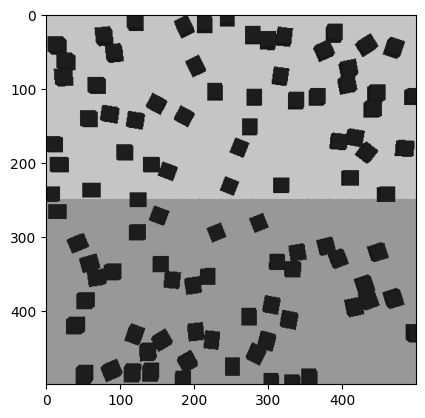

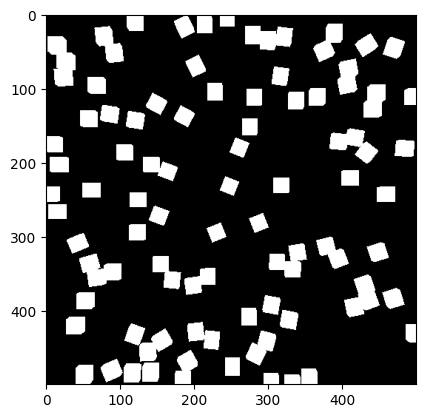

In [6]:
# Initialize preprocessor module and preprocess the environment
preprocess = PreprocessEnvironment(    
    boundary_points=boundary_points,
    push_width=shovel_width,  
    stochasticity=True,
    grid_size=grid_size,
    binary_grid=False
    )

occ_grid, total_ooccupied = preprocess.transform_pybullet_image_to_grid(top_view_gray, rect_size=np.shape(top_view_gray)[:2], square_size=SQUARE_SIZE, debug=True)
total_pixels_in_cell = preprocess.total_pixels_in_cell
print(f"✓ Preprocessing complete: Occupied cells = {total_ooccupied}, Total pixels in cell = {total_pixels_in_cell}")

Stochastic push enabled.


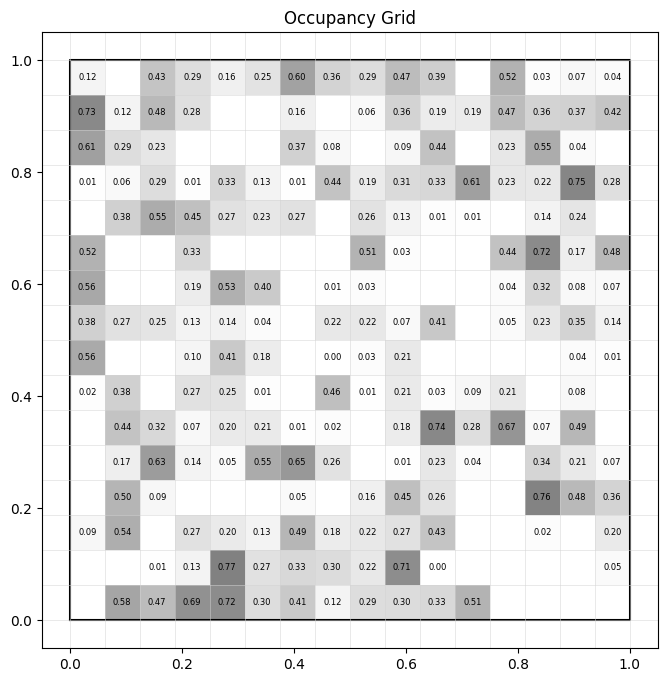

In [7]:
# Create environment
stochastic_env = PushEnvironmentGym(
                                    boundary_points=boundary_points,
                                    delta_s_options=delta_s_options,
                                    theta_options=theta_options,
                                    push_width=shovel_width, 
                                    initial_pos=s0,          
                                    max_pushes=max_pushes,
                                    coverage_thresh=coverage_threshold,
                                    occupancy_grid=occ_grid,
                                    total_occupied=total_ooccupied,
                                    total_pixels_in_cell=total_pixels_in_cell,
                                    stochasticity=True,
                                    grid_size=grid_size,
                                    action_prune=True
                                )
stochastic_env.draw_grid_environment(stochastic_env.initial_state['grid_mask'])

In [8]:
agent_path = os.path.join(project_root, "algorithms/rl-agents")
sys.path.append(agent_path)
from rl_agents.agents.tree_search.mcts import MCTSAgent
# from rl_agents.agents.tree_search.mcts_dpw import MCTSDPWAgent

agent = MCTSAgent(env=stochastic_env, config=dict(horizon=max_pushes, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSDPWAgent(env=stochastic_env, config=dict(horizon=3, episodes=10000, gamma=0.8, temperature=50, closed_loop=True, k_state=2, alpha_state=0.3, k_action=3, alpha_action=0.3))

number of actions=288
Initial state:
Start idx=0
Starting MCTS planning...
episodes: 10000, horizon: 3, budget
temperature: 50, gamma: 0.8
Get refined actions called
Refined 18 children nodes [(-3, 1.5707963267948966), (-1, 1.5707963267948966), (-3, 3.141592653589793), (-3, 2.356194490192345), (-1, 3.141592653589793), (-3, 2.748893571891069), (-3, 1.9634954084936207), (-1, 2.356194490192345), (-1, 2.748893571891069), (-3, 0.0), (-1, 1.9634954084936207), (-1, 0.0), (-3, 1.1780972450961724), (-3, 0.39269908169872414), (-1, 1.1780972450961724), (-3, 0.7853981633974483), (-1, 0.39269908169872414), (-1, 0.7853981633974483)]
Get refined actions called
Refined 18 children nodes [(1, 1.1780972450961724), (3, 1.5707963267948966), (1, 0.7853981633974483), (3, 1.1780972450961724), (3, 2.356194490192345), (3, 3.141592653589793), (1, 1.5707963267948966), (3, 1.9634954084936207), (3, 2.748893571891069), (1, 1.9634954084936207), (3, 0.0), (1, 3.141592653589793), (1, 2.356194490192345), (1, 2.74889357

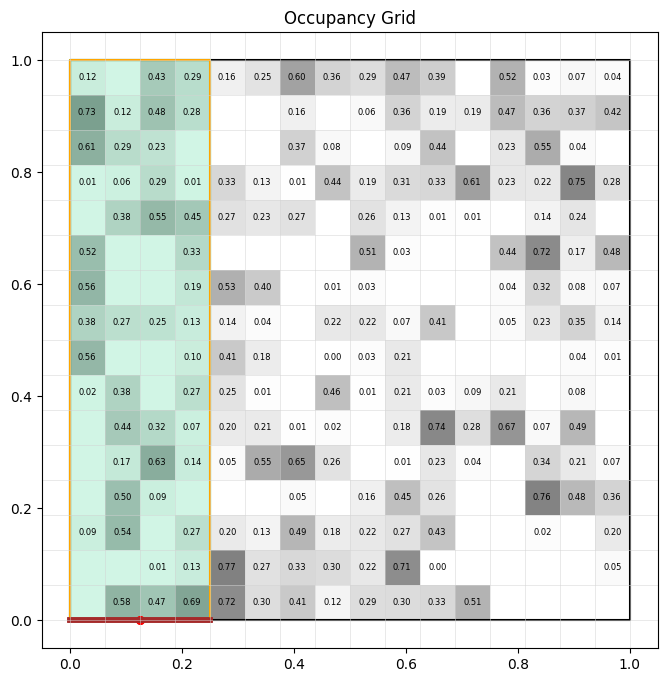

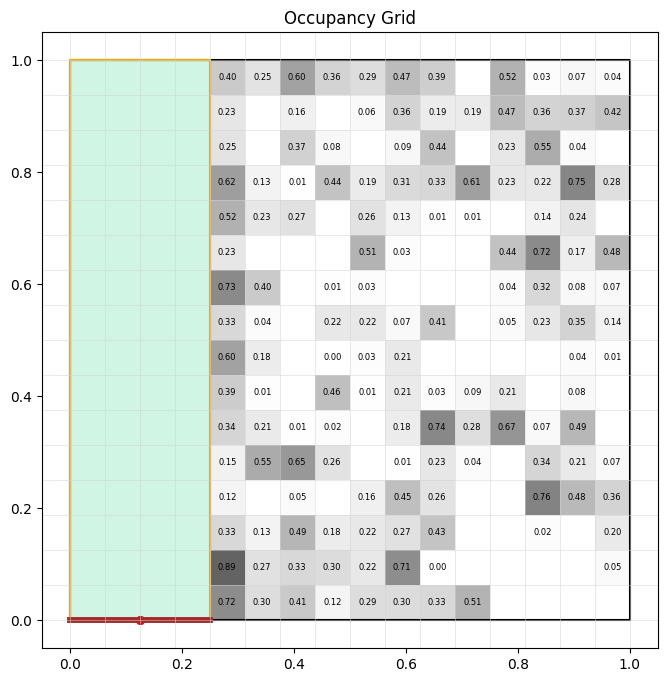

############ mcts action is 160
delta_s: 2, theta: 157.5 deg
############ state is {'s_idx': 37, 'grid_mask': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0. 

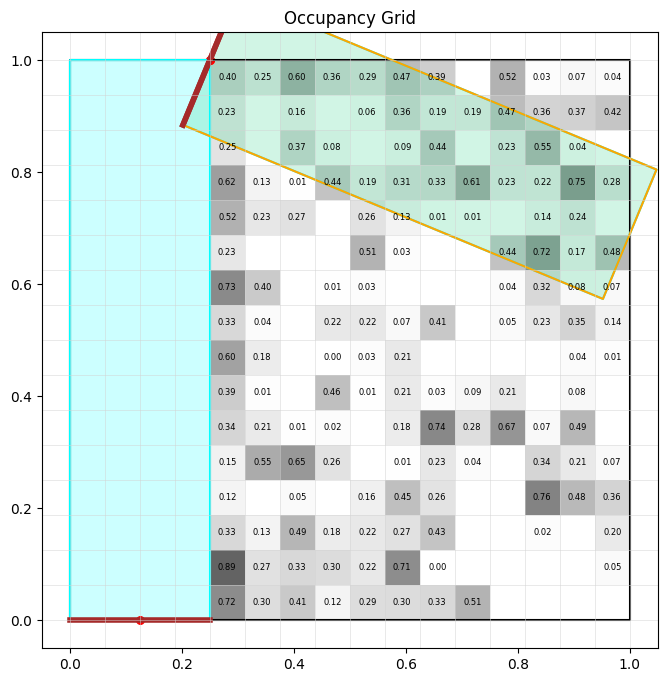

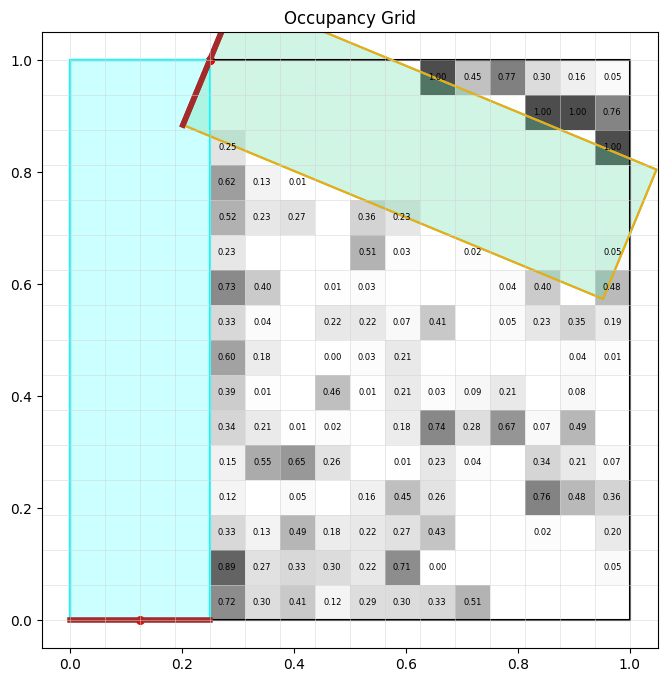

############ mcts action is 106
delta_s: -10, theta: 157.5 deg
############ state is {'s_idx': 34, 'grid_mask': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0

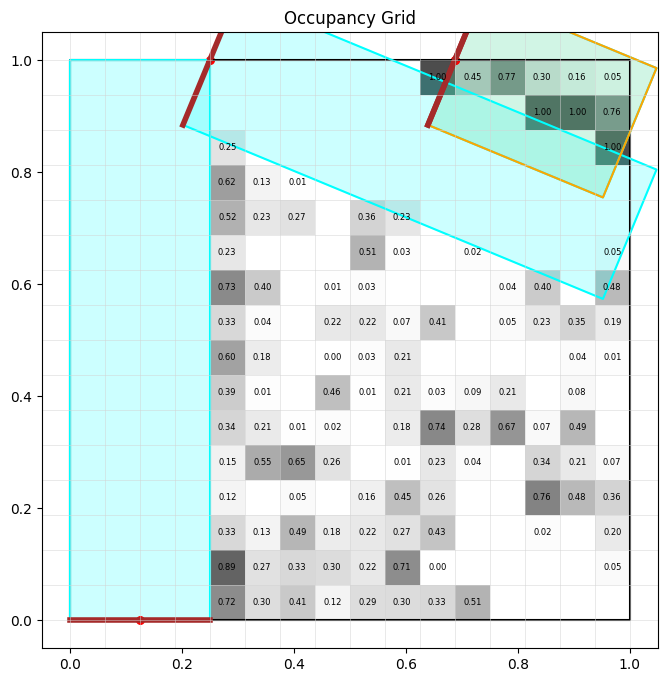

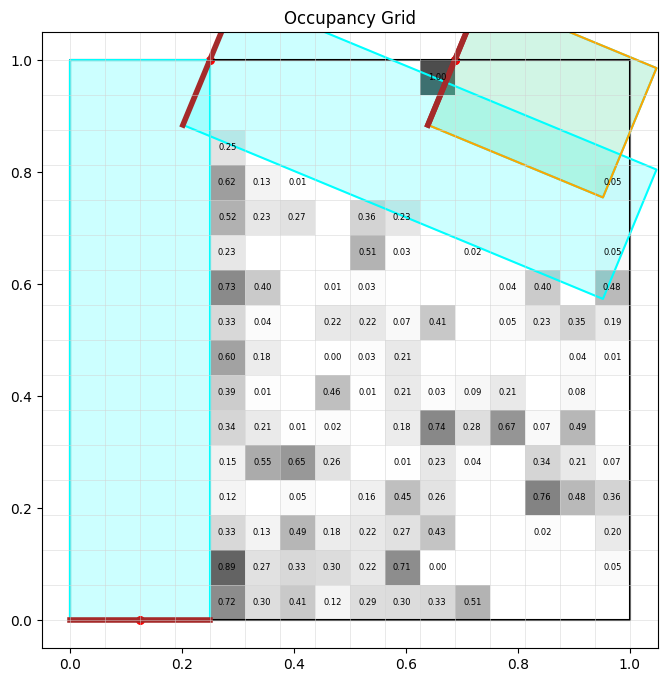

Episode finished after 3 steps with total reward 0.2303
Coverage threshold reached: 46.00%
OR Reached the end of the environment or maximum pushes.
final_coverage: 0.46000532034623165 final_length: 48.400667404970704 final_reward: -0.025451861450113245
total_reward: 0.23032789417275001


In [9]:
# Reset environment and get initial state
state, info = stochastic_env.reset()
done = truncated = False
total_reward = 0

initial_state = stochastic_env.initial_state.copy()
current_state = state
push_env = stochastic_env.get_push_env()

pushes = []
normed_pushes = []
normed_path = []
global_pushes = []
global_path = []

normed_start_point = push_env.transform_s_to_normed_world(initial_state['s_idx'])
alpha_start = 0.0  # Initial alpha is 0.0
alpha = alpha_start
normed_path.append((normed_start_point, alpha))  # Add initial position with initisl alpha of 0.0
global_start_point = push_env.transform_normed_world_to_global(normed_start_point)
alpha_global = alpha  # Initial alpha is 0.0
global_path.append((global_start_point, alpha_global))  # Add initial position and alpha to global path

print("number of actions={}".format(len(push_env.action_space)))

print("Initial state:")
print(f"Start idx={initial_state['s_idx']}")
print("Starting MCTS planning...")
optimal_path = agent.act_offline(state)
print("Optimal path (action indices):", optimal_path)
for step, action in enumerate(optimal_path):
    # MCTS planning to find best action
    print("############ mcts action is", action)
    
    # Convert action index back to delta_s, theta
    # The action_space in the new environment maps indices to (delta_s, theta) pairs
    if isinstance(action, (int, np.integer)):
        delta_s, theta = push_env.action_space[action]
    else:
        delta_s, theta = action
    # delta_s, theta = push_env.action_space[action]
    print(f"delta_s: {delta_s}, theta: {np.degrees(theta):.1f} deg")
    
    prev_state = state
    s_before = prev_state['s_idx']

    # Take the action in the environment
    state, reward, done, truncated, info = stochastic_env.step(action)

    print("############ state is", state)
    print("############ reward is", reward)
    print("############ done", done)

    total_reward += reward
    
    push_len = info.get('t_max', 0)
    print("push_len", push_len)
    
    if delta_s is not None and theta is not None:
        print(f"Push {step+1}: Start idx={s_before}, delta_s={delta_s}, theta={np.degrees(theta):.1f} deg, reward={reward:.4f}")
        print("length", state['length'])

    uncovered = np.count_nonzero(state['grid_mask'])
    coverage = stochastic_env.compute_coverage(state['grid_mask'])
    print(f"coverage: {coverage} \n")

    normed_corner1, normed_corner2 = push_env.find_boundry_corners_in_ds_path(s_before, delta_s)
    print(f"s_corner1: {normed_corner1}, s_corner2: {normed_corner2}")
    if normed_corner1 is not None:
        normed_path.append((normed_corner1, alpha))
        global_corner1 = push_env.transform_normed_world_to_global(normed_corner1)
        global_path.append((global_corner1, alpha_global))
    if normed_corner2 is not None:
        normed_path.append((normed_corner2, alpha))
        global_corner2 = push_env.transform_normed_world_to_global(normed_corner2)
        global_path.append((global_corner2, alpha_global))
    start_point, end_point, alpha = push_env.transform_push_to_normed_world(s_before, delta_s, theta)
    print(f"Normed start_point: {start_point}, Normed end_point: {end_point}, Normed alpha: {alpha}")
    normed_path.append((start_point, alpha))
    normed_path.append((end_point, alpha))

    start_point_global, end_point_global, alpha_global = push_env.transform_push_to_global_world(s_before, delta_s, theta)
    print(f"Global start_point: {start_point_global}, Global end_point: {end_point_global}, Global alpha: {alpha_global}")
    global_path.append((start_point_global, alpha_global))
    global_path.append((end_point_global, alpha_global))

    direction = np.array([np.cos(alpha), np.sin(alpha)])

    pushes.append((start_point, direction))
    normed_pushes.append((start_point, end_point, alpha))
    global_pushes.append((start_point_global, end_point_global, alpha_global))

    stochastic_env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    stochastic_env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))

    if done or truncated:
        print(f"Episode finished after {step+1} steps with total reward {total_reward:.4f}")

print(f"Coverage threshold reached: {coverage*100:.2f}%")
print("OR Reached the end of the environment or maximum pushes.")
print("final_coverage:", stochastic_env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
# print("final_coverage:", stochastic_env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
# max_total_length = ((grid_size * (1 / shovel_width)) + grid_size - shovel_width * 0.5)
# normed_length = state['length'] / max_total_length
# print("normed_length:", normed_length)
# print("cov/length ratio:", coverage / normed_length)
print("total_reward:", total_reward)

## Section 4: Test Positions and Control


In [10]:
def trnsformation_from_global_to_robot_base_coordinates(global_pos):
    # This function should implement the transformation from global coordinates to robot base coordinates
    x_base, y_base = -0.1, 0.25  # Robot base position in global coordinates
    theta_base = 0.0  # Robot base orientation in radians

    # Convert global_pos to robot base coordinates
    x_global, y_global = global_pos
    x_robot = (x_global - x_base) * np.cos(theta_base) + (y_global - y_base) * np.sin(theta_base)
    y_robot = -(x_global - x_base) * np.sin(theta_base) + (y_global - y_base) * np.cos(theta_base)

    return (x_robot, y_robot)

def transform_normed_yaw_to_robot_yaw(alpha):
    # Convert a normalized yaw angle to global world coordinates using the bounding box size and offset
    robot_alpha = alpha
    robot_alpha = (robot_alpha + np.pi) % (2 * np.pi) - np.pi  # Normalize to [-pi, pi] 
    
    return robot_alpha

In [11]:
def transform_path_to_robot_base_coordinates(path):
    # This function takes a path defined in global coordinates and transforms it to robot base coordinates
    robot_base_path = []
    for (point, alpha) in path:
        point_robot = trnsformation_from_global_to_robot_base_coordinates(point)
        yaw_robot = transform_normed_yaw_to_robot_yaw(alpha)
        robot_base_path.append((point_robot, yaw_robot))
    return robot_base_path

In [12]:
print("Optimal path found by MCTS:")
# print(optimal_path)
# print(normed_path)
print(global_path)
# global_path =  [(np.array([0., 0.]), 0.0), (np.array([0., 0.]), 0.7853981633974483), (np.array([0.5, 0.5]), 0.7853981633974483), (np.array([0.375, 0.5  ]), 3.9269908169872414), (np.array([0.   , 0.125]), 3.9269908169872414), (np.array([0.    , 0.0625]), 1.178097245096172), (np.array([0.18121843, 0.5       ]), 1.178097245096172)]
print("Global path (in global coordinates):", global_path)
robot_path = transform_path_to_robot_base_coordinates(global_path)
print("robot_path:", robot_path)

positions = []

for pose in robot_path:
    pos, alpha = pose
    positions.append([pos[0], pos[1], alpha])
print("Global positions and orientations of pushes:")
print(positions)

print("Path Positions (x [m], y [m], theta [deg]):")
for i, pos in enumerate(positions):
    print(f"  Position {i+1}: x={pos[0]:.2f}m, y={pos[1]:.2f}m, theta={np.degrees(pos[2]):.1f}°")

Optimal path found by MCTS:
[(array([0., 0.]), 0.0), (array([0., 0.]), 0.0), (array([0.0625, 0.    ]), 1.5707963267948966), (array([0.0625, 0.5   ]), 1.5707963267948966), (array([0.125, 0.5  ]), 5.890486225480862), (array([0.5       , 0.34466991]), 5.890486225480862), (array([0.5, 0.5]), 5.890486225480862), (array([0.34375, 0.5    ]), 5.890486225480862), (array([0.5       , 0.43527913]), 5.890486225480862)]
Global path (in global coordinates): [(array([0., 0.]), 0.0), (array([0., 0.]), 0.0), (array([0.0625, 0.    ]), 1.5707963267948966), (array([0.0625, 0.5   ]), 1.5707963267948966), (array([0.125, 0.5  ]), 5.890486225480862), (array([0.5       , 0.34466991]), 5.890486225480862), (array([0.5, 0.5]), 5.890486225480862), (array([0.34375, 0.5    ]), 5.890486225480862), (array([0.5       , 0.43527913]), 5.890486225480862)]
robot_path: [((0.1, -0.25), 0.0), ((0.1, -0.25), 0.0), ((0.1625, -0.25), 1.5707963267948966), ((0.16250000000000003, 0.25), 1.5707963267948966), ((0.225, 0.25), -0.39269

## Section 5a: Execute Sequential Control and Visualize Trajectory


## Section 5b: Velocity Control Mode (Alternative)
Use VELOCITY_CONTROL for strict velocity constraints (joint position is still tracked but velocity is directly controlled)

Position 1: x=0.10m, y=-0.25m, theta=0.0°
Moving to target position 1 (VELOCITY_CONTROL): x=0.10m, y=-0.25m, theta=0.0°

Starting velocity control to target:
  Target: X=0.1000, Y=-0.2500, Theta=0.00°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 860
  Position error: 0.002128m
  Theta error: -1.0000°


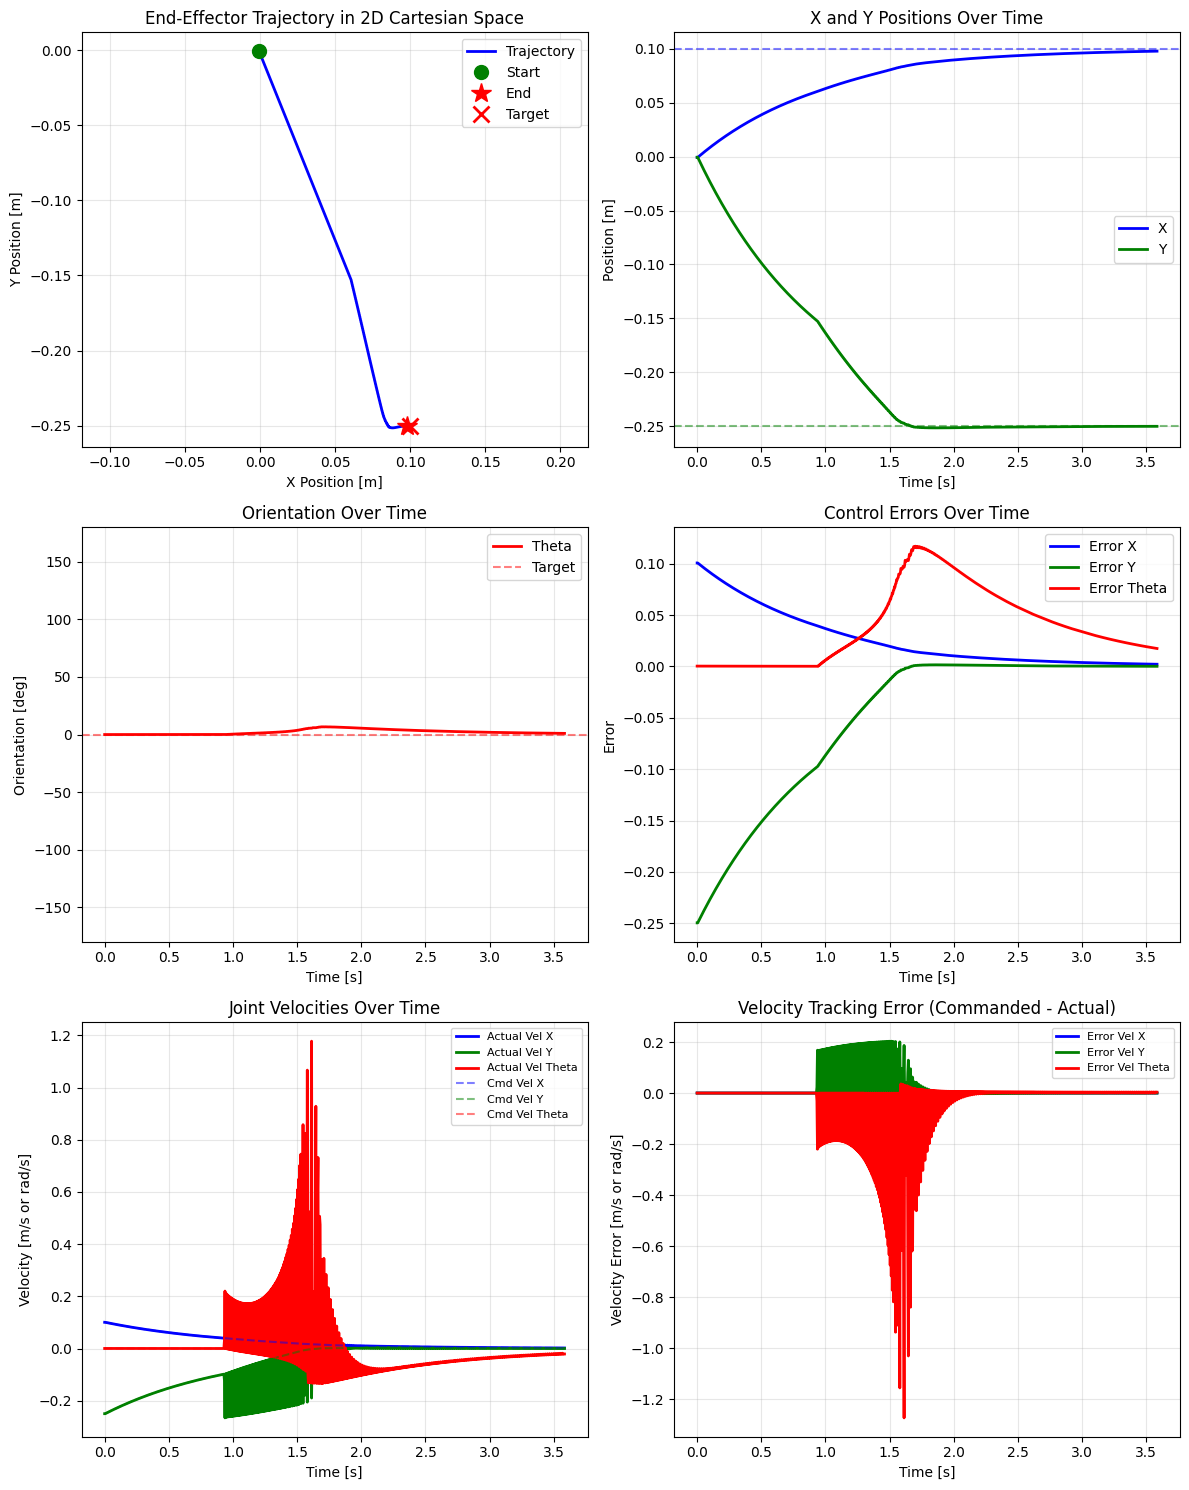


Final State:
  Position: (0.0979m, -0.2501m)
  Orientation: 1.00°
  Final Joint Velocities: X=0.0021, Y=0.0001, Theta=-0.0209
  Final Commanded Velocities: X=0.0021, Y=0.0001, Theta=-0.0175
Target Position:   (0.1000m, -0.2500m, 0.00°)

✓ Velocity control execution complete


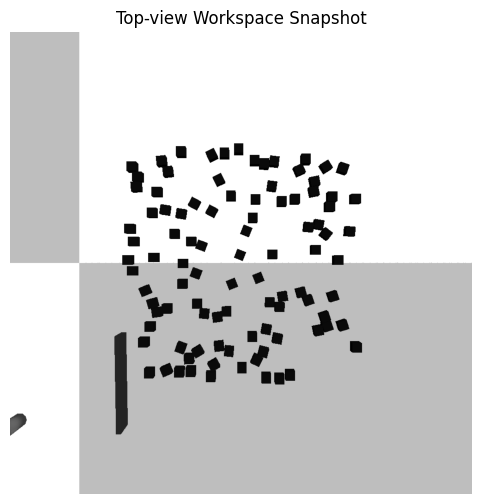

Position 2: x=0.10m, y=-0.25m, theta=0.0°
Moving to target position 2 (VELOCITY_CONTROL): x=0.10m, y=-0.25m, theta=0.0°

Starting velocity control to target:
  Target: X=0.1000, Y=-0.2500, Theta=0.00°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 0
  Position error: 0.002119m
  Theta error: -0.9950°


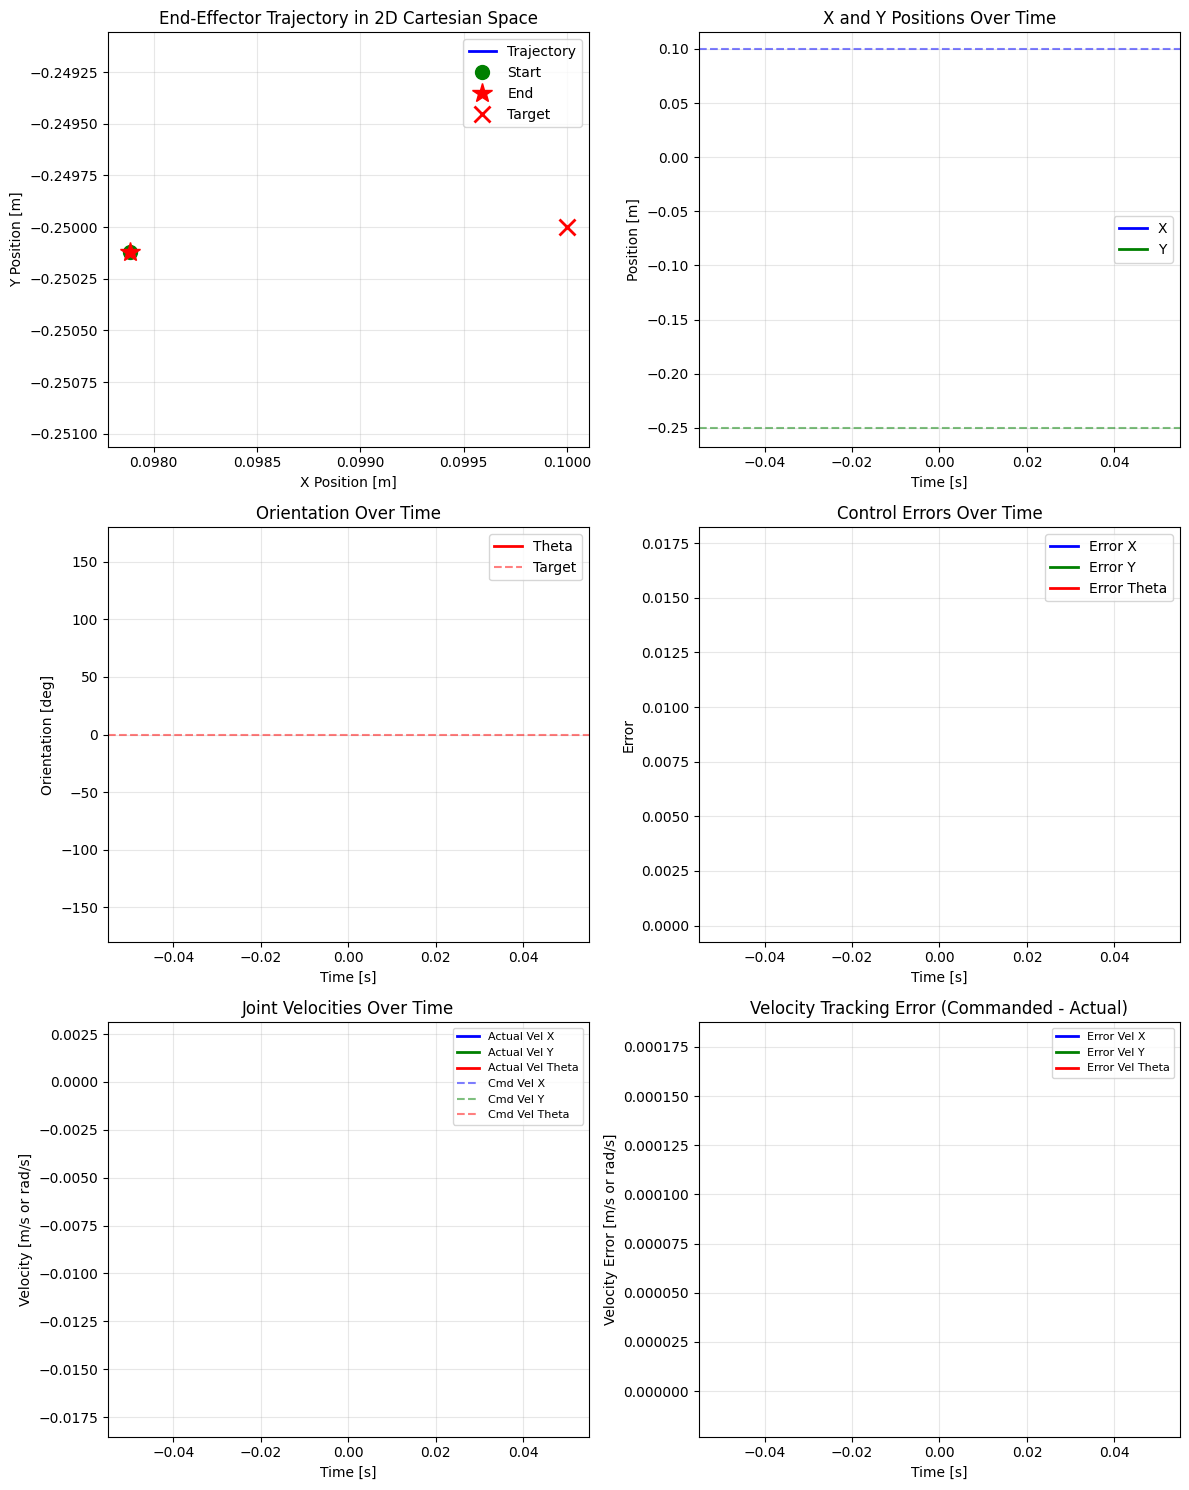


Final State:
  Position: (0.0979m, -0.2501m)
  Orientation: 0.99°
  Final Joint Velocities: X=0.0021, Y=0.0001, Theta=-0.0175
  Final Commanded Velocities: X=0.0021, Y=0.0001, Theta=-0.0174
Target Position:   (0.1000m, -0.2500m, 0.00°)

✓ Velocity control execution complete


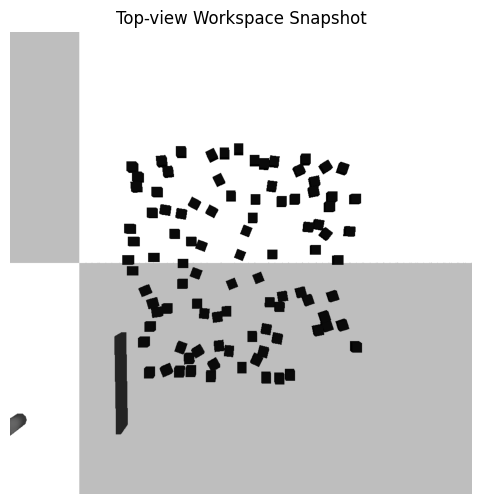

Position 3: x=0.16m, y=-0.25m, theta=90.0°
Moving to target position 3 (VELOCITY_CONTROL): x=0.16m, y=-0.25m, theta=90.0°

Starting velocity control to target:
  Target: X=0.1625, Y=-0.2500, Theta=90.00°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 604
  Position error: 0.000973m
  Theta error: 0.9992°


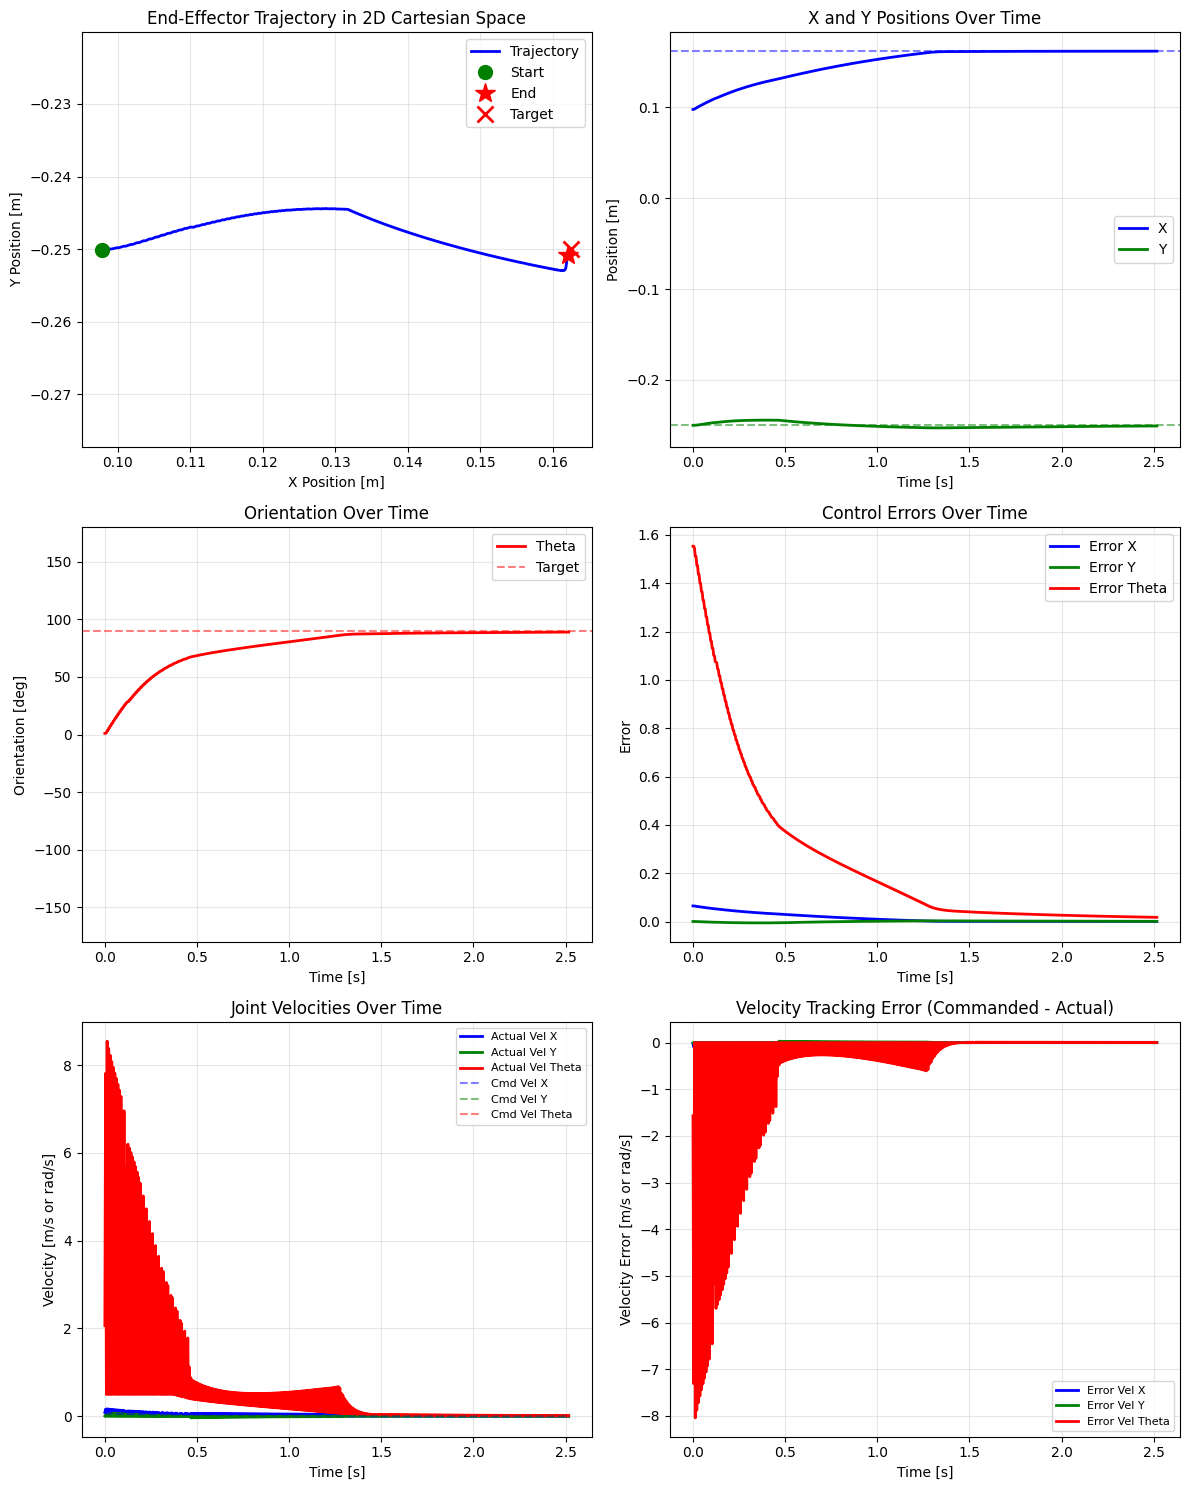


Final State:
  Position: (0.1620m, -0.2509m)
  Orientation: 89.00°
  Final Joint Velocities: X=0.0005, Y=0.0009, Theta=0.0175
  Final Commanded Velocities: X=0.0005, Y=0.0009, Theta=0.0174
Target Position:   (0.1625m, -0.2500m, 90.00°)

✓ Velocity control execution complete


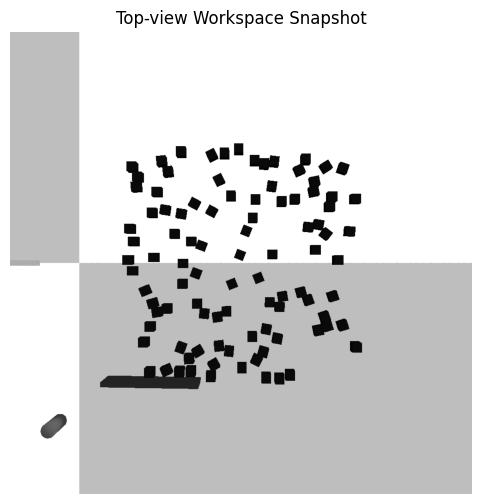

Position 4: x=0.16m, y=0.25m, theta=90.0°
Moving to target position 4 (VELOCITY_CONTROL): x=0.16m, y=0.25m, theta=90.0°

Starting velocity control to target:
  Target: X=0.1625, Y=0.2500, Theta=90.00°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 937
  Position error: 0.009973m
  Theta error: 0.0581°


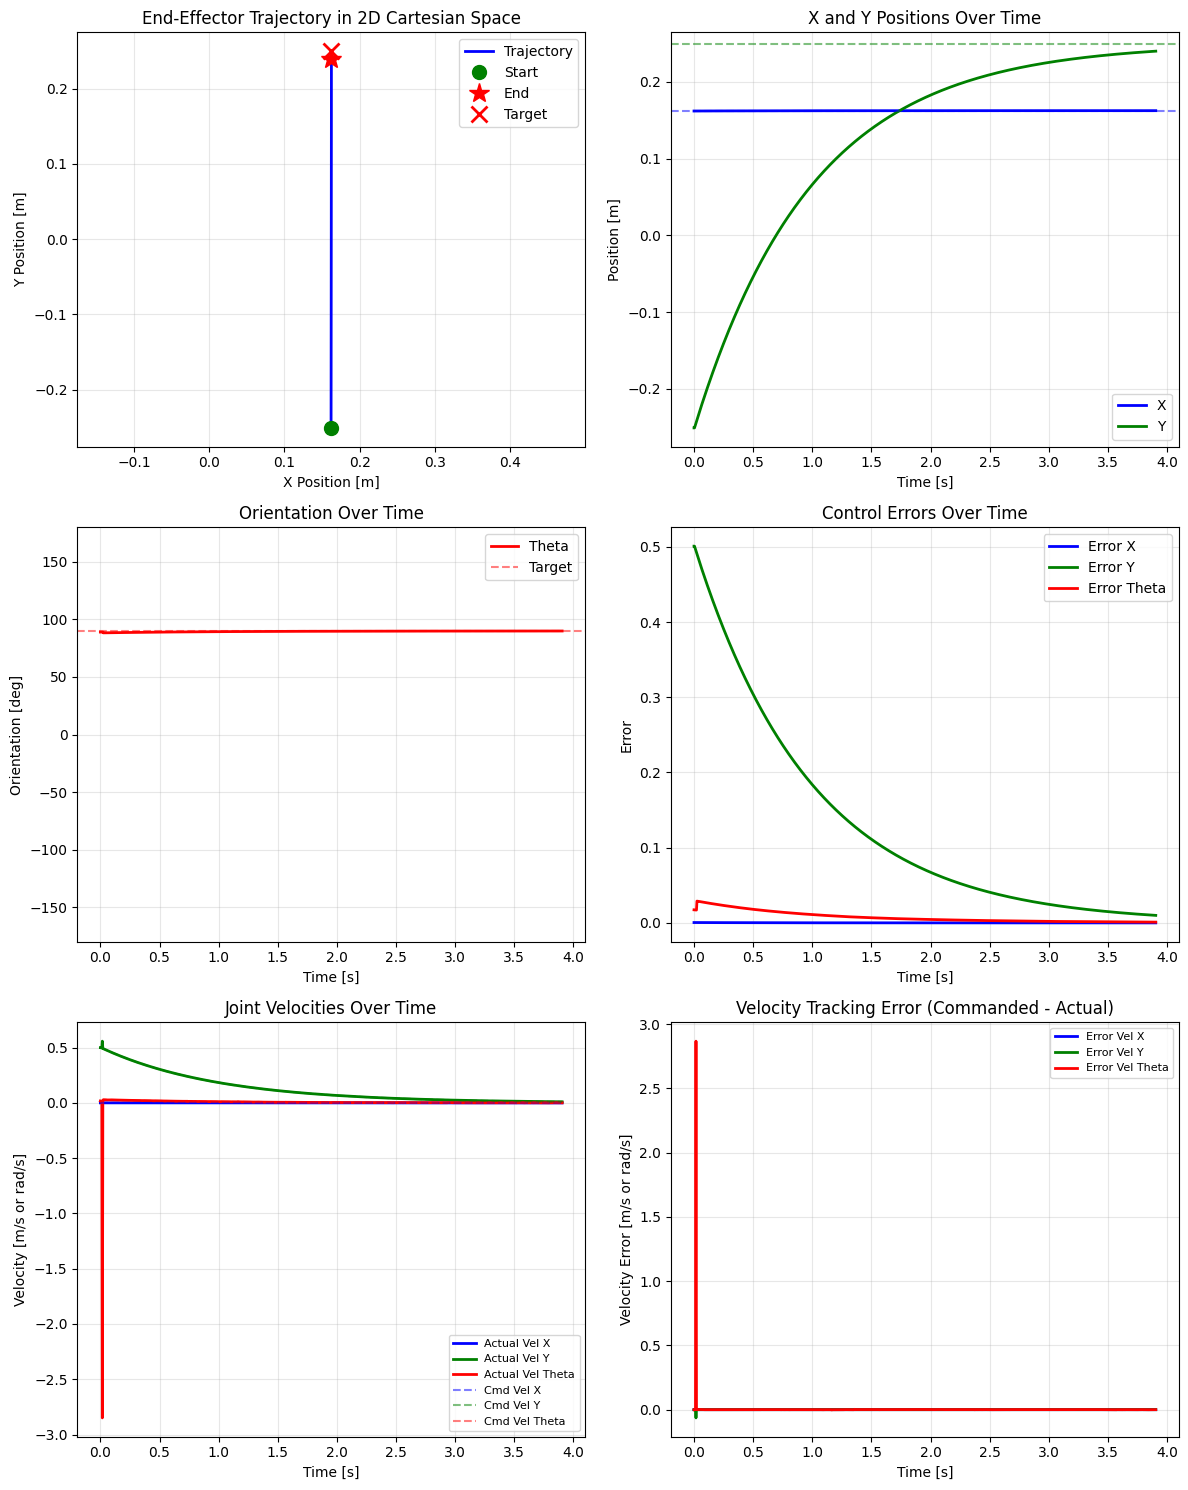


Final State:
  Position: (0.1625m, 0.2400m)
  Orientation: 89.94°
  Final Joint Velocities: X=-0.0000, Y=0.0099, Theta=0.0008
  Final Commanded Velocities: X=-0.0000, Y=0.0100, Theta=0.0010
Target Position:   (0.1625m, 0.2500m, 90.00°)

✓ Velocity control execution complete


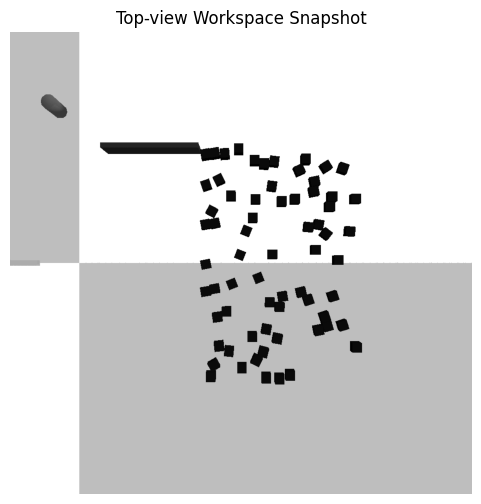

Position 5: x=0.23m, y=0.25m, theta=-22.5°
Moving to target position 5 (VELOCITY_CONTROL): x=0.23m, y=0.25m, theta=-22.5°

Starting velocity control to target:
  Target: X=0.2250, Y=0.2500, Theta=-22.50°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 1498
  Position error: 0.000120m
  Theta error: -0.9957°


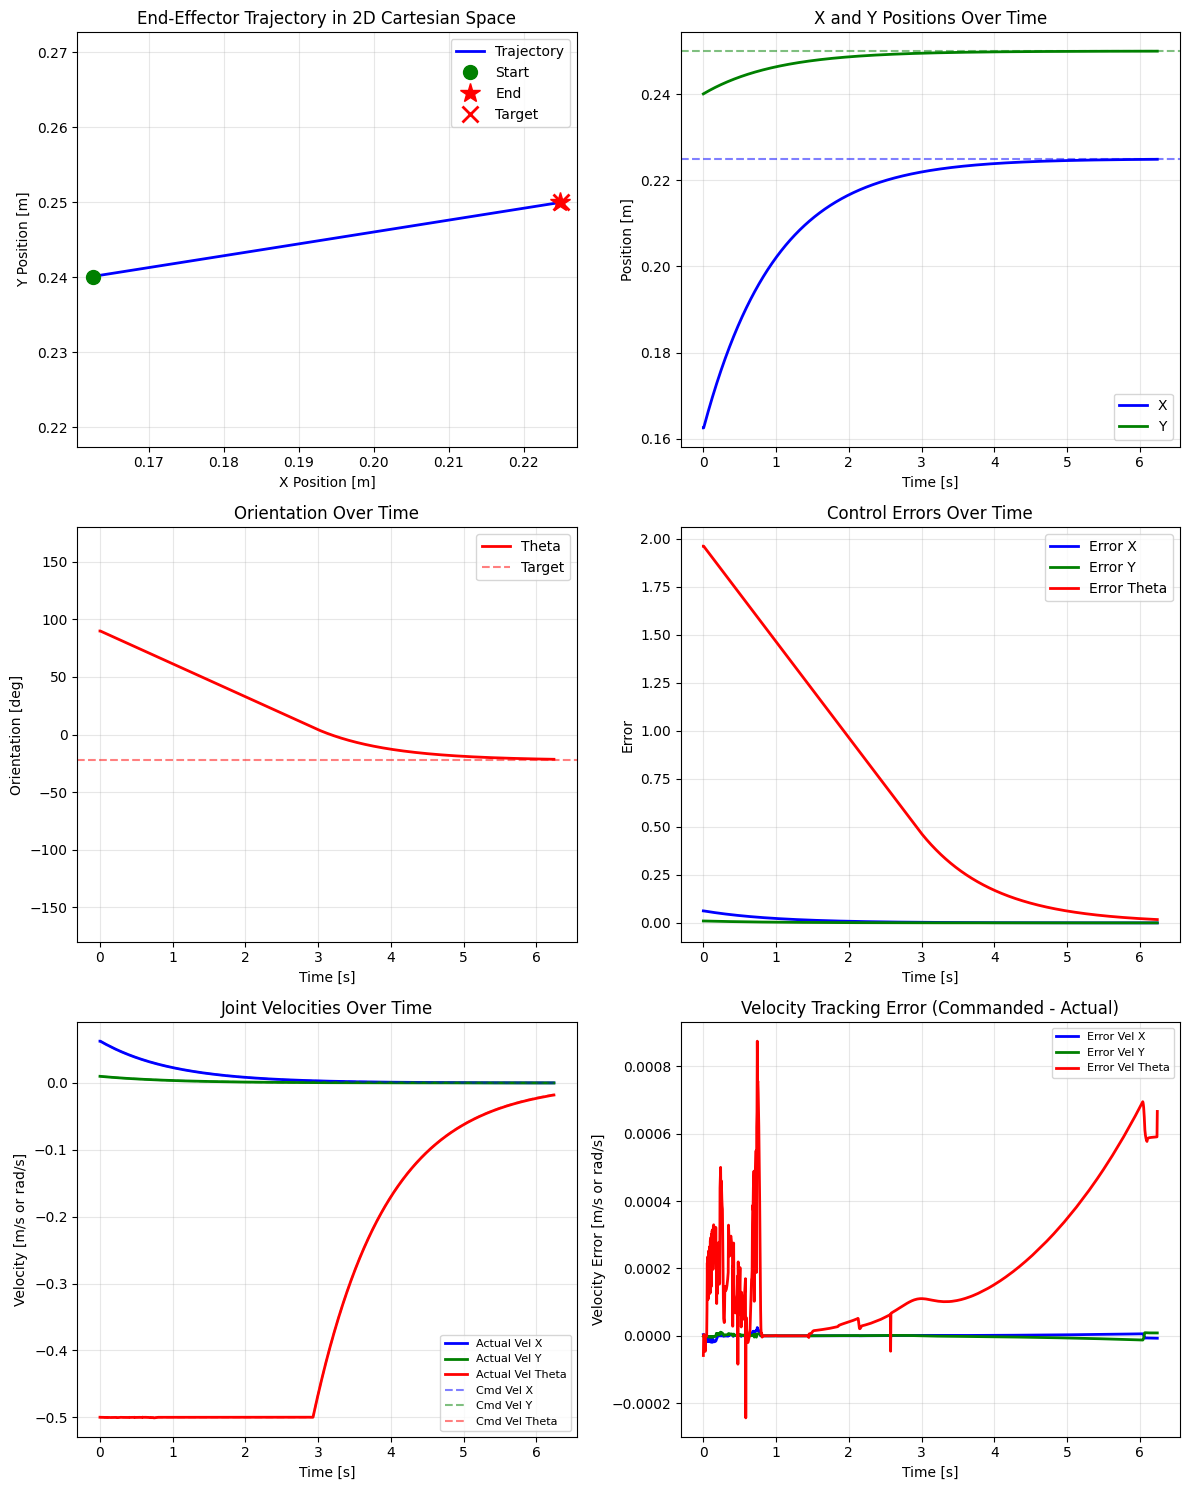


Final State:
  Position: (0.2249m, 0.2500m)
  Orientation: -21.50°
  Final Joint Velocities: X=0.0001, Y=0.0000, Theta=-0.0180
  Final Commanded Velocities: X=0.0001, Y=0.0000, Theta=-0.0174
Target Position:   (0.2250m, 0.2500m, -22.50°)

✓ Velocity control execution complete


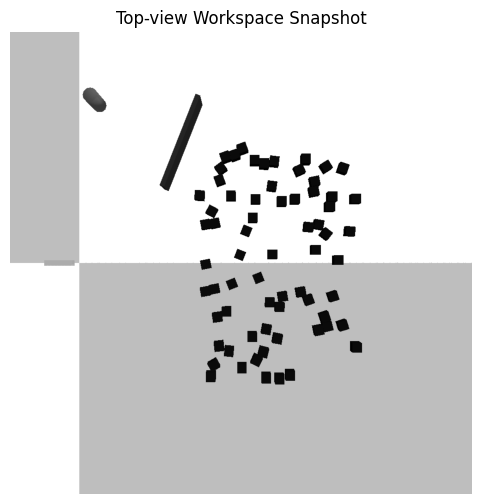

Position 6: x=0.60m, y=0.09m, theta=-22.5°
Moving to target position 6 (VELOCITY_CONTROL): x=0.60m, y=0.09m, theta=-22.5°

Starting velocity control to target:
  Target: X=0.6000, Y=0.0947, Theta=-22.50°
  Max velocity: 0.5000 rad/s or m/s

ⓘ Max steps (5000) reached without convergence
  Final position error: 0.034466m


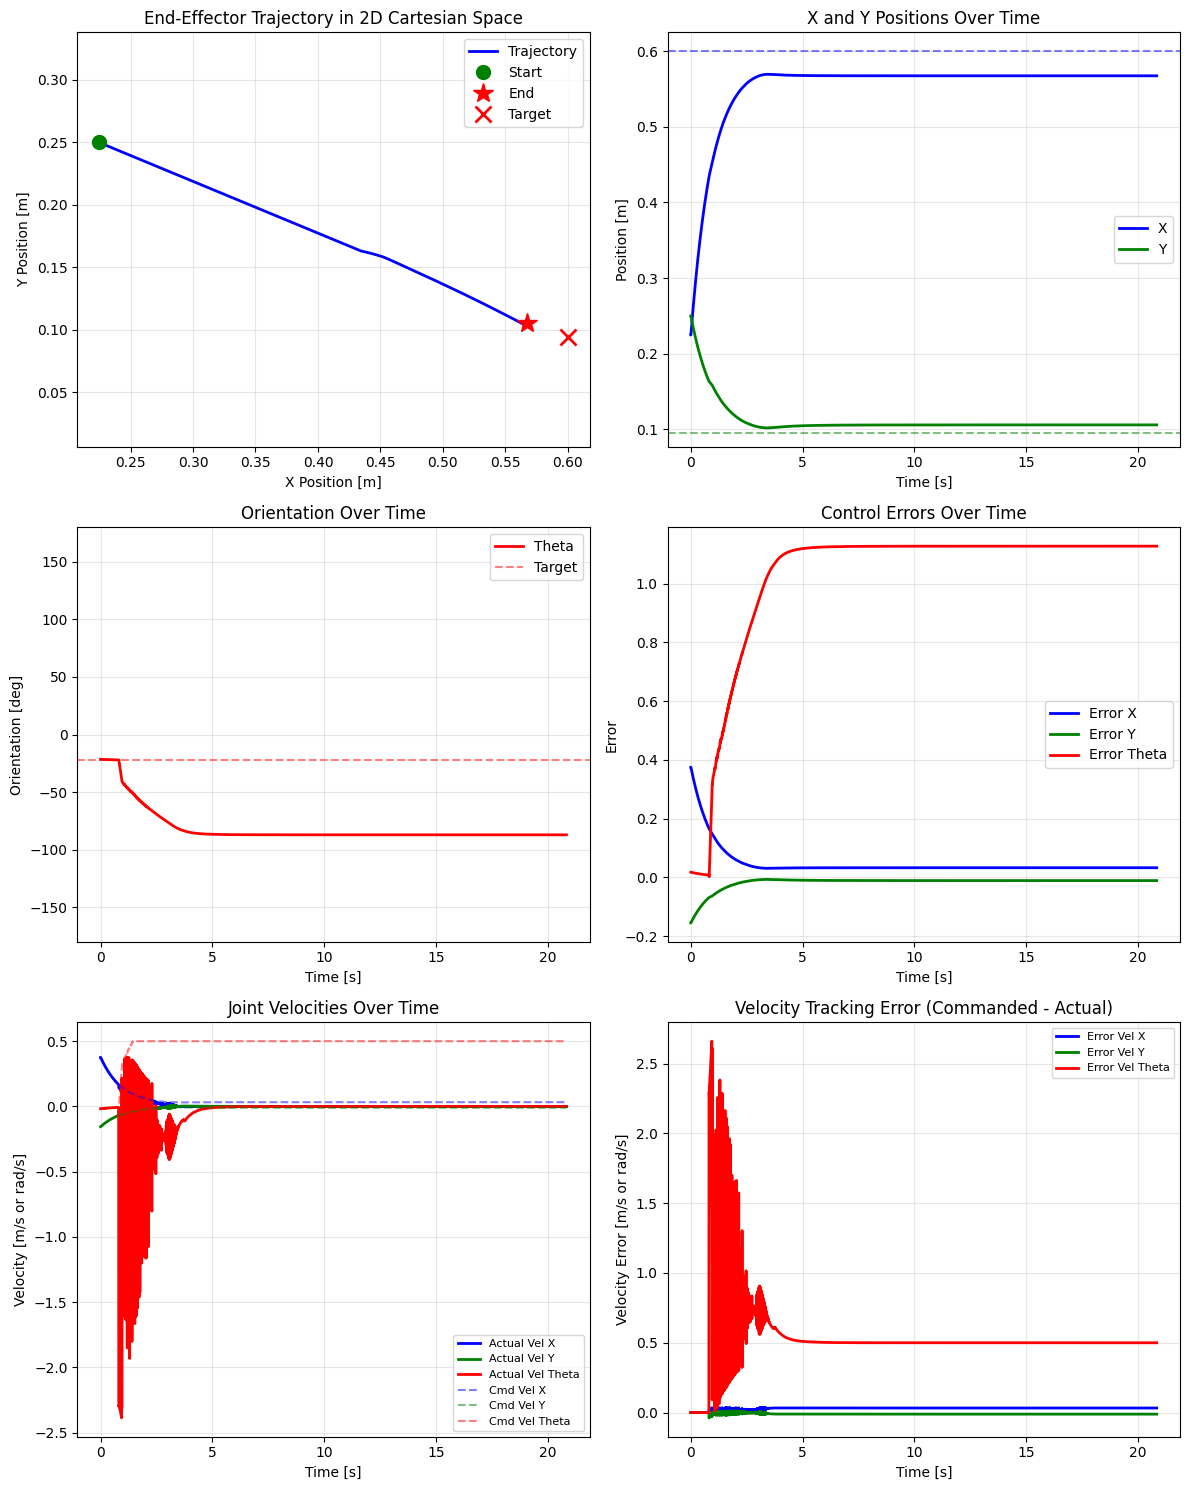


Final State:
  Position: (0.5674m, 0.1059m)
  Orientation: -87.14°
  Final Joint Velocities: X=-0.0000, Y=-0.0000, Theta=-0.0000
  Final Commanded Velocities: X=0.0326, Y=-0.0112, Theta=0.5000
Target Position:   (0.6000m, 0.0947m, -22.50°)

✓ Velocity control execution complete


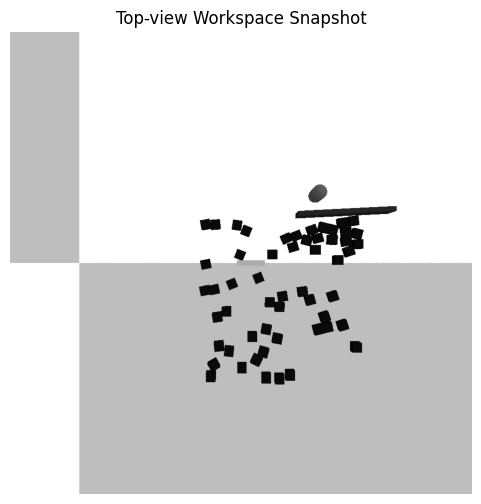

Position 7: x=0.60m, y=0.25m, theta=-22.5°
Moving to target position 7 (VELOCITY_CONTROL): x=0.60m, y=0.25m, theta=-22.5°

Starting velocity control to target:
  Target: X=0.6000, Y=0.2500, Theta=-22.50°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 1104
  Position error: 0.001616m
  Theta error: 0.9986°


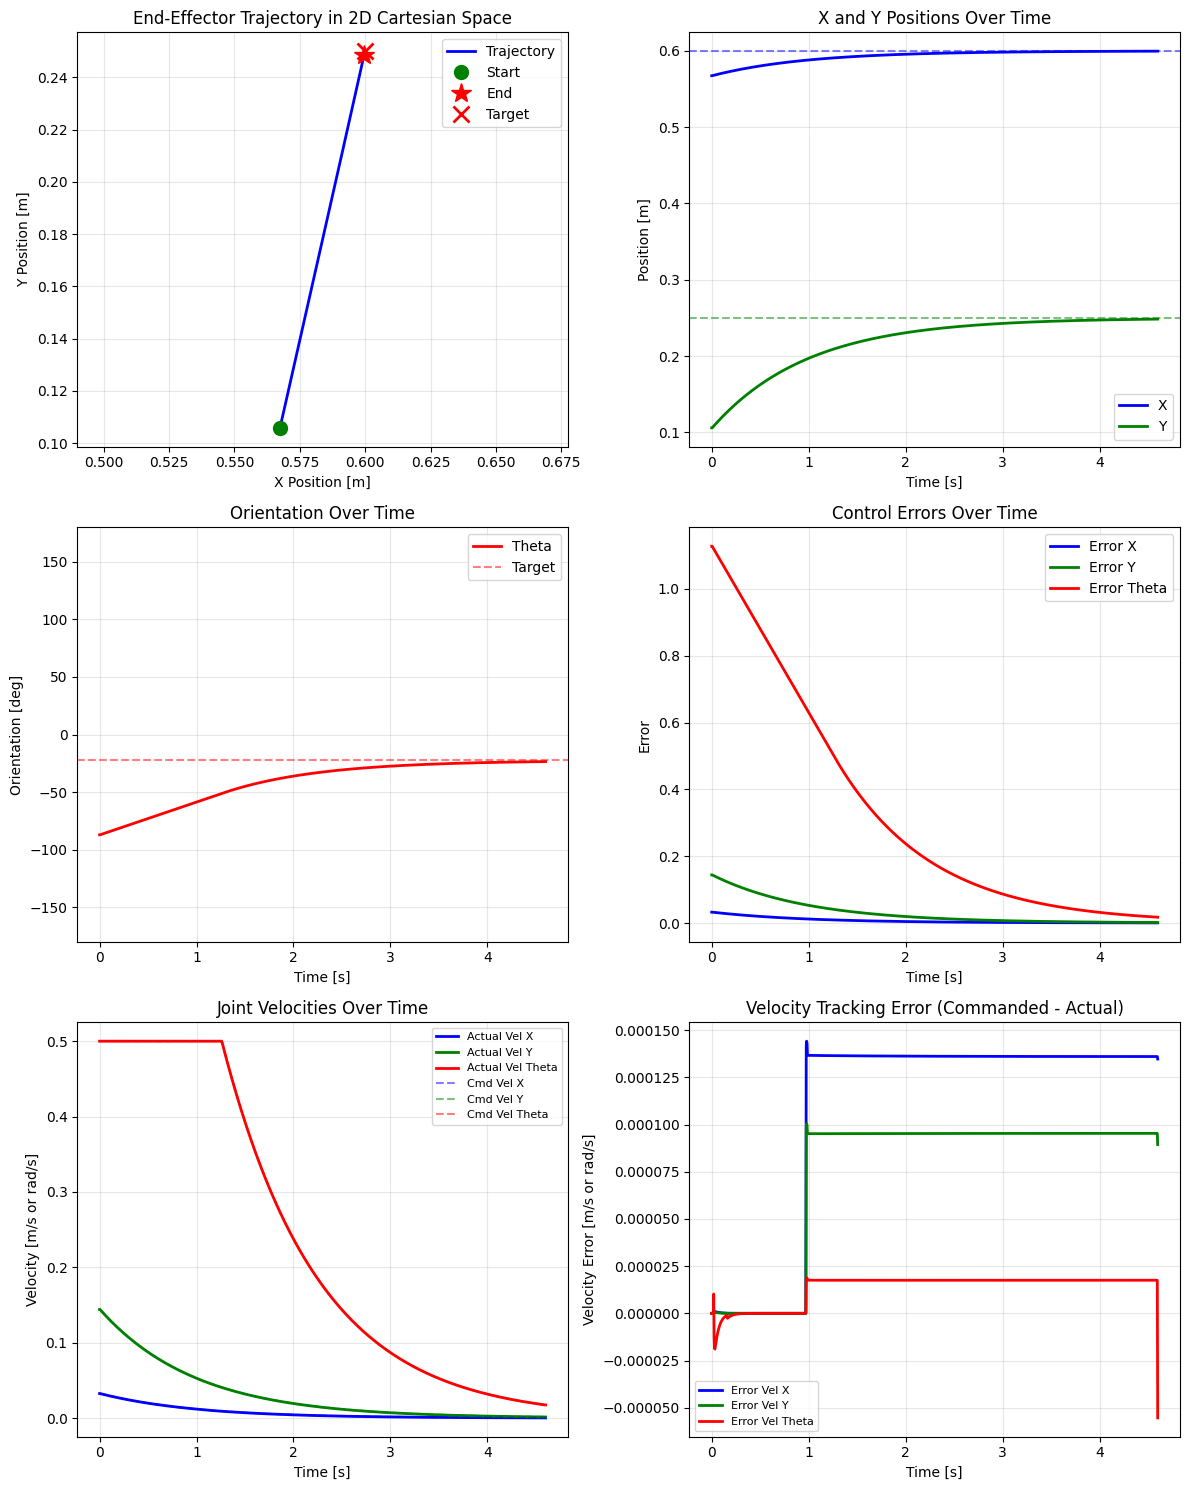


Final State:
  Position: (0.5996m, 0.2484m)
  Orientation: -23.50°
  Final Joint Velocities: X=0.0003, Y=0.0015, Theta=0.0175
  Final Commanded Velocities: X=0.0004, Y=0.0016, Theta=0.0174
Target Position:   (0.6000m, 0.2500m, -22.50°)

✓ Velocity control execution complete


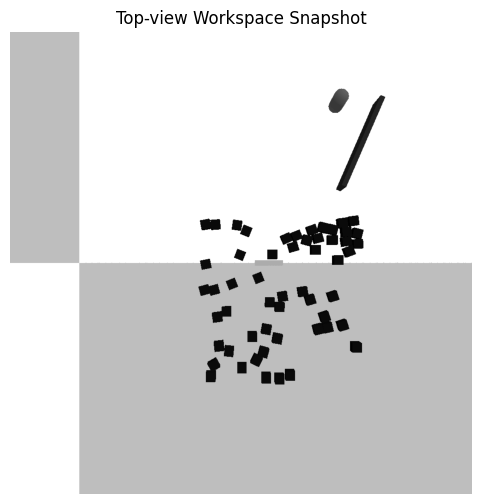

Position 8: x=0.44m, y=0.25m, theta=-22.5°
Moving to target position 8 (VELOCITY_CONTROL): x=0.44m, y=0.25m, theta=-22.5°

Starting velocity control to target:
  Target: X=0.4437, Y=0.2500, Theta=-22.50°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 654
  Position error: 0.009970m
  Theta error: 0.0681°


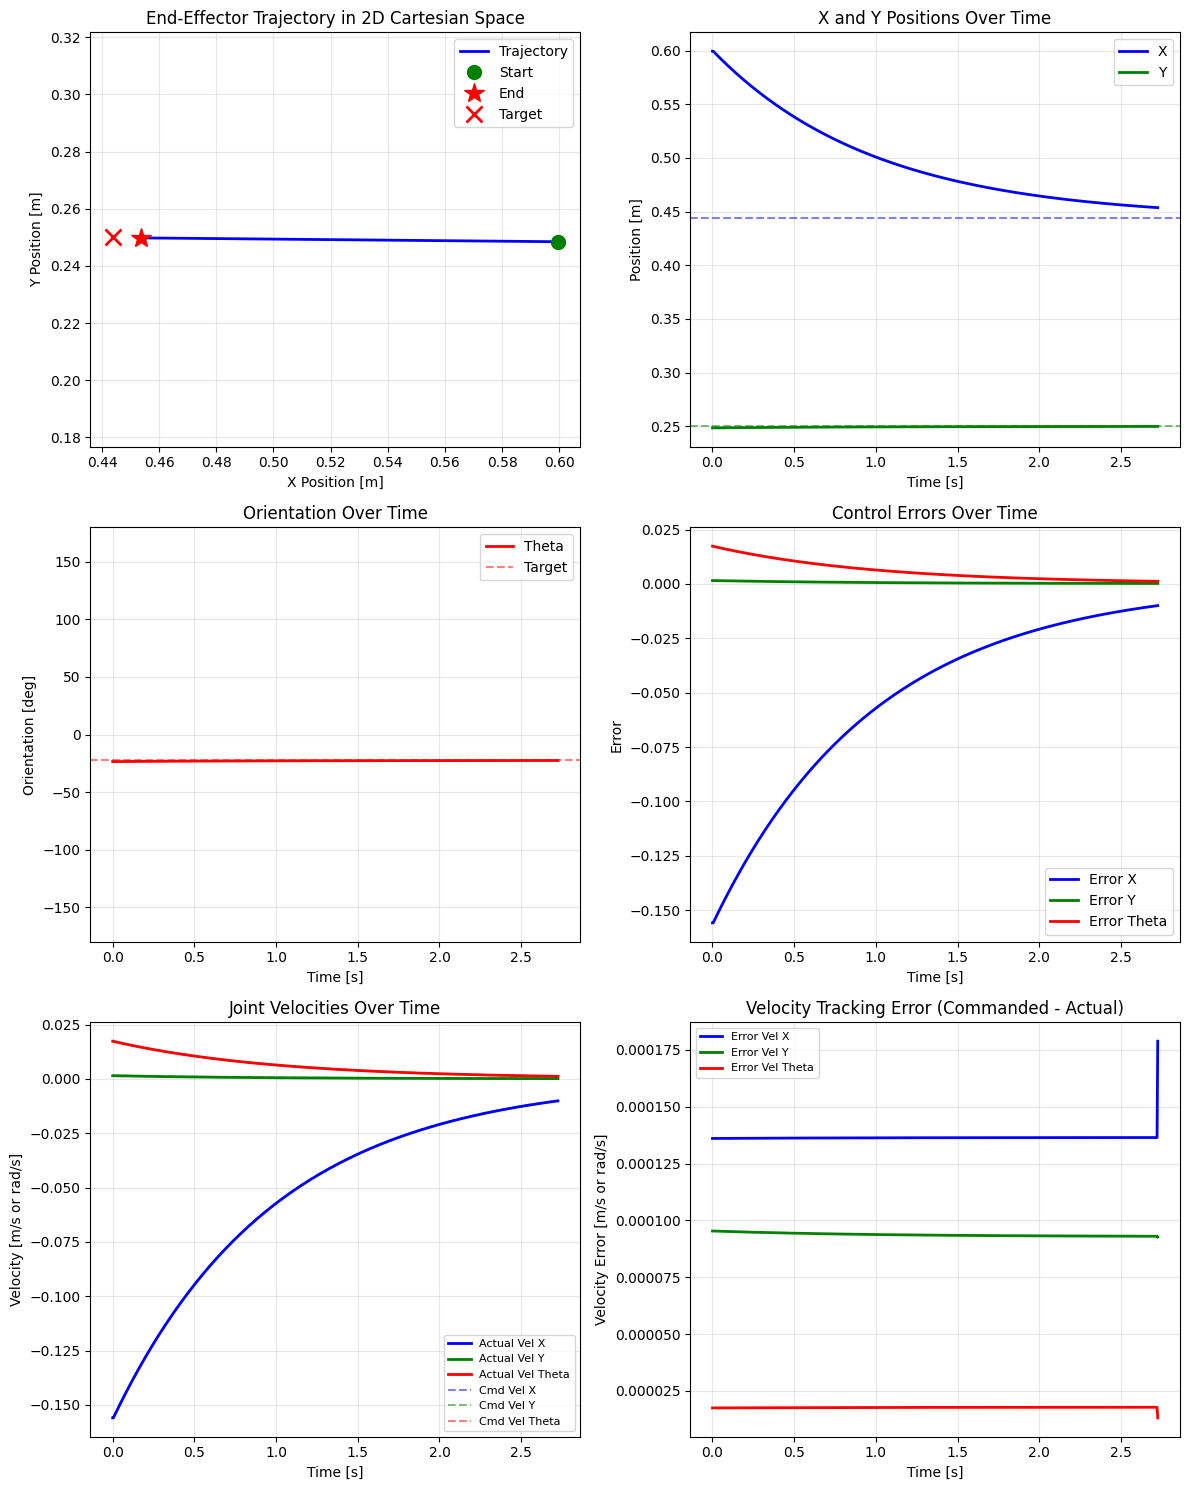


Final State:
  Position: (0.4537m, 0.2498m)
  Orientation: -22.57°
  Final Joint Velocities: X=-0.0101, Y=0.0001, Theta=0.0012
  Final Commanded Velocities: X=-0.0100, Y=0.0002, Theta=0.0012
Target Position:   (0.4437m, 0.2500m, -22.50°)

✓ Velocity control execution complete


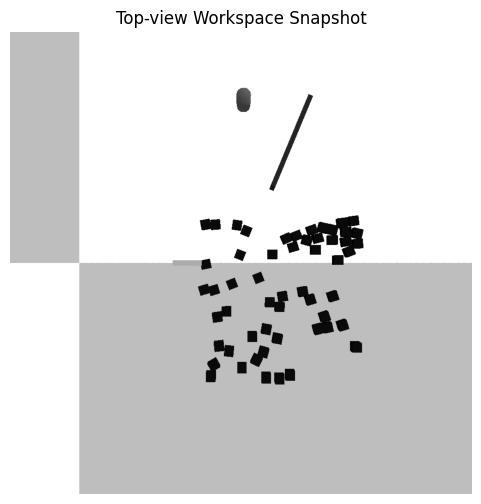

Position 9: x=0.60m, y=0.19m, theta=-22.5°
Moving to target position 9 (VELOCITY_CONTROL): x=0.60m, y=0.19m, theta=-22.5°

Starting velocity control to target:
  Target: X=0.6000, Y=0.1853, Theta=-22.50°
  Max velocity: 0.5000 rad/s or m/s

✓ Target reached at step 663
  Position error: 0.009964m
  Theta error: 0.0138°


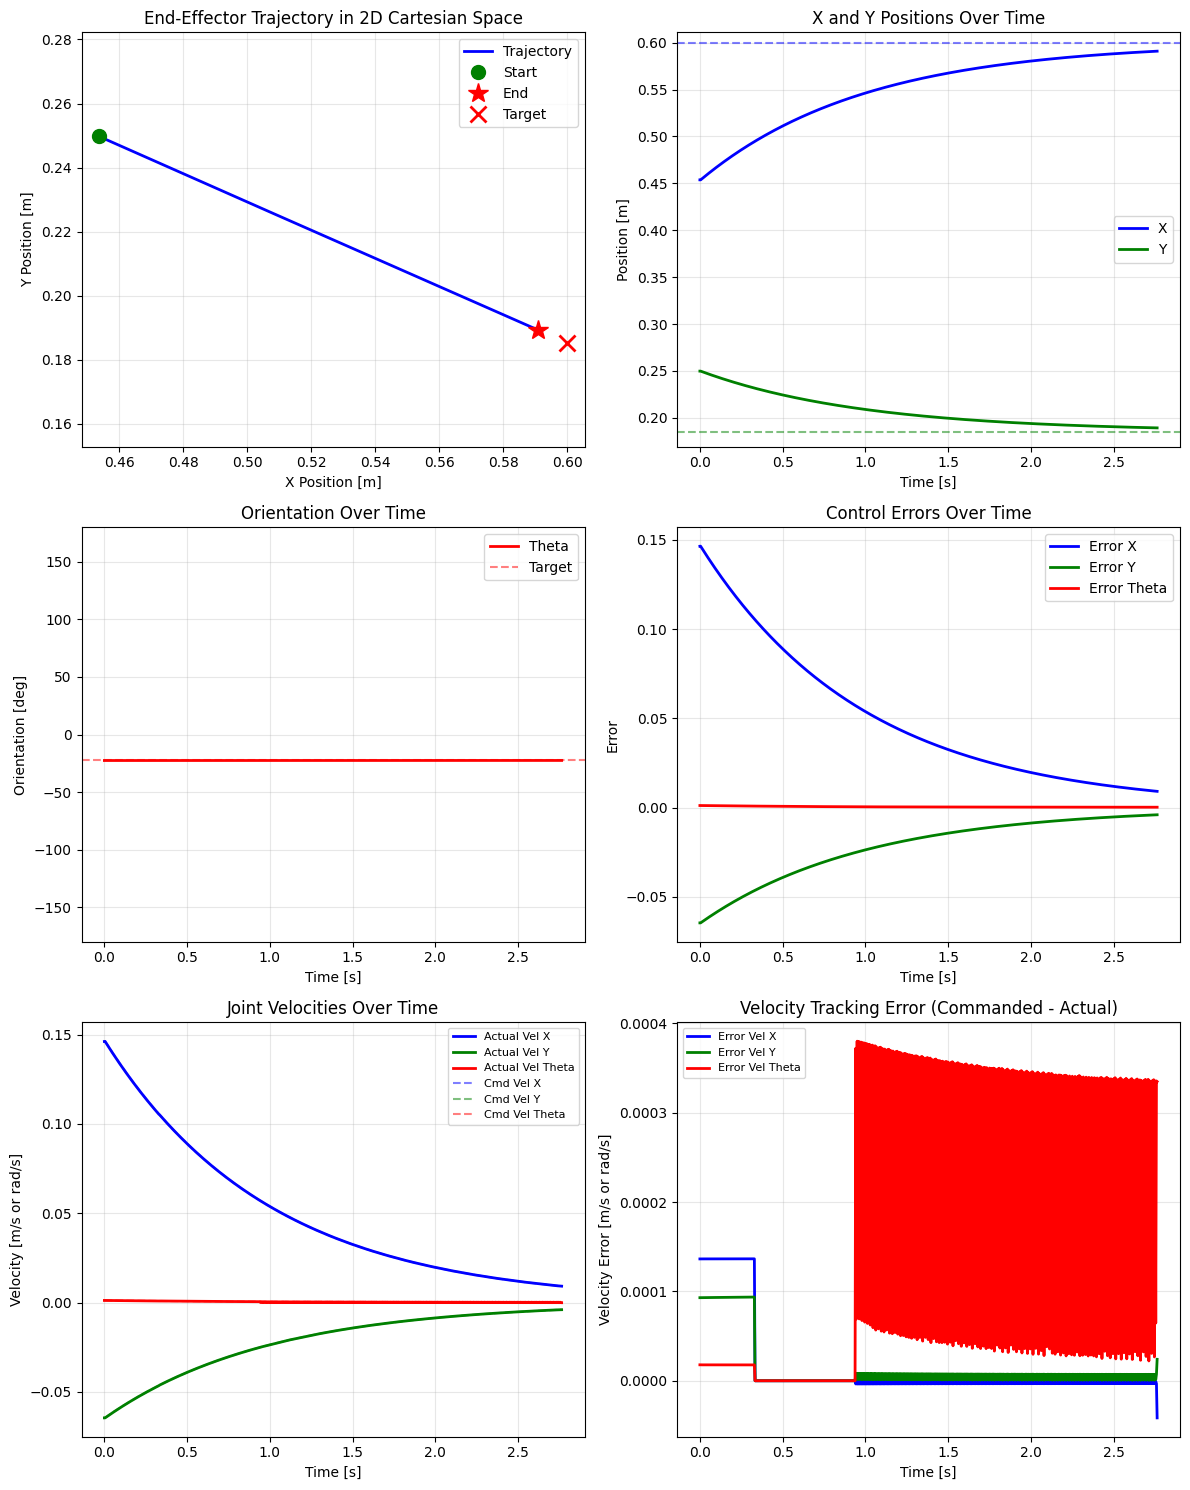


Final State:
  Position: (0.5909m, 0.1893m)
  Orientation: -22.51°
  Final Joint Velocities: X=0.0092, Y=-0.0040, Theta=-0.0001
  Final Commanded Velocities: X=0.0091, Y=-0.0040, Theta=0.0002
Target Position:   (0.6000m, 0.1853m, -22.50°)

✓ Velocity control execution complete


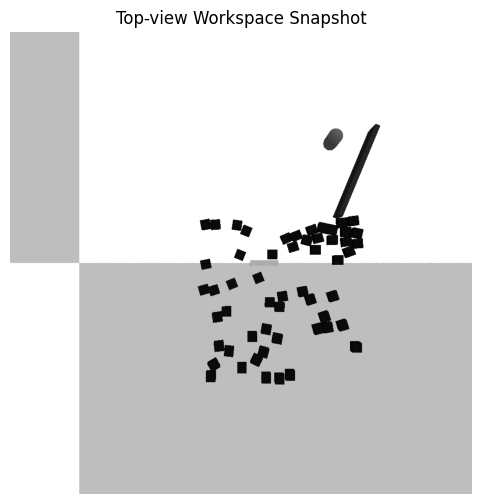

In [13]:
# Test velocity control mode (tracks position while enforcing strict velocity limits)
# target_idx = 2
# target_idx = 0
for i, pos in enumerate(positions):
    print(f"Position {i+1}: x={pos[0]:.2f}m, y={pos[1]:.2f}m, theta={np.degrees(pos[2]):.1f}°")
    target = positions[i]

    print(f"Moving to target position {i + 1} (VELOCITY_CONTROL): x={target[0]:.2f}m, y={target[1]:.2f}m, theta={np.degrees(target[2]):.1f}°\n")

    trajectory_vel, errors_vel, joint_velocities_vel, commanded_velocities_vel = controller.apply_cartesian_control_velocity_mode(
        target[0], target[1], target[2],
        # max_velocity=0.15,
        max_velocity=0.5,
        max_force=10000,
        # max_force=5000,
        # max_force=100,
        tolerance=0.01,
        max_steps=5000
    )

    # Step the simulation to ensure all commands are processed and results are updated
    physics_env.step()

    # Plot results - shows actual vs commanded velocities
    controller.plot_trajectory_results(trajectory_vel, errors_vel, target, joint_velocities_vel, commanded_velocities_vel, mode='velocity')

    print(f"\n✓ Velocity control execution complete")

    top_view_gray = controller.get_top_view(pixel_width=1000, pixel_height=1000, camera_target_pos=[0.35, 0, 0], camera_distance=0.866)

    # Display in notebook
    plt.figure(figsize=(6, 6))
    plt.imshow(top_view_gray[:, :, 0], cmap='gray')
    plt.title('Top-view Workspace Snapshot')
    plt.axis('off')
    plt.show()

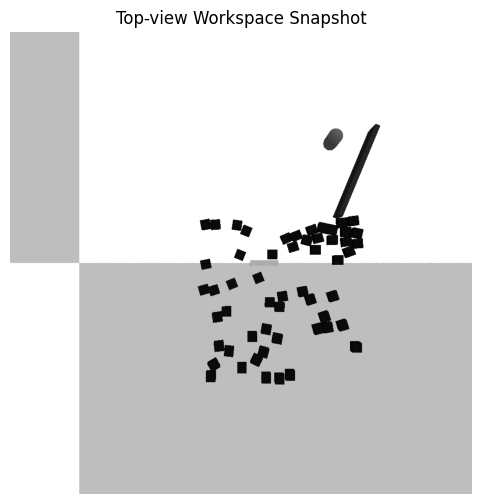

In [14]:
# Capture and display workspace top-view
top_view_gray = controller.get_top_view(pixel_width=1000, pixel_height=1000, camera_target_pos=[0.35, 0, 0], camera_distance=0.866)

# Save to output directory
# snapshot_path = controller.save_top_view()

# Display in notebook
plt.figure(figsize=(6, 6))
plt.imshow(top_view_gray[:, :, 0], cmap='gray')
plt.title('Top-view Workspace Snapshot')
plt.axis('off')
plt.show()

# print(f"✓ Snapshot saved to: {snapshot_path.resolve()}")


In [15]:
# Cleanup when done
# Uncomment to close the simulation
# p.disconnect()
physics_env.close()

print("✓ Simulation is running. Use p.disconnect() to close when done.")

✓ Simulation is running. Use p.disconnect() to close when done.
